# Import Dependencies

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GroupKFold, KFold, train_test_split

from src.features import add_missing_indicators
from src.modeling.evaluate import evaluate_feature_set, evaluate_holdout, run_experiments
from src.modeling.train import build_catboost

# Load Data

In [3]:
df = pd.read_csv("../data/raw/train.csv", index_col="sample_id")
df.head()

,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,biome,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
sample_id,,,,,,,,,,,,,,,,,,,,,
train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,Cerrado,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,Amazonia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11210 entries, train_00001 to train_11210
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   source_id                 11210 non-null  object 
 1   has_band_A_spectrum       11210 non-null  object 
 2   has_band_B_spectrum       11210 non-null  object 
 3   sampling_strategy         11210 non-null  object 
 4   sampling_depth_cm         11210 non-null  object 
 5   geo_zone_macro            11210 non-null  object 
 6   geo_zone_micro            11210 non-null  object 
 7   geo_zone_meso             11210 non-null  object 
 8   land_cover_type           11210 non-null  object 
 9   biome                     11210 non-null  object 
 10  parent_rock_type          11210 non-null  object 
 11  property_particle_coarse  10458 non-null  float64
 12  property_particle_fine    10443 non-null  float64
 13  property_organic_content  11210 non-null  float64


# Missing Value Engineering

## EDA: Pola Missing Value

In [5]:
df.isna().mean().mul(100).sort_values(ascending=False).round(2)

cation_Na                   96.41
spectral_band_B_PC_15       84.89
spectral_band_B_PC_8        84.89
spectral_band_B_PC_12       84.89
spectral_band_B_PC_1        84.89
spectral_band_B_PC_3        84.89
spectral_band_B_PC_2        84.89
spectral_band_B_PC_6        84.89
spectral_band_B_PC_5        84.89
spectral_band_B_PC_7        84.89
spectral_band_B_PC_4        84.89
spectral_band_B_PC_14       84.89
spectral_band_B_PC_9        84.89
spectral_band_B_PC_10       84.89
spectral_band_B_PC_11       84.89
spectral_band_B_PC_13       84.89
latitude                    78.68
longitude                   78.68
property_acidity_index      74.98
cation_Mg                   10.97
cation_exchange_capacity    10.96
cation_Ca                   10.96
property_particle_fine       6.84
property_particle_coarse     6.71
sampling_depth_cm            0.00
geo_zone_macro               0.00
geo_zone_micro               0.00
sampling_strategy            0.00
source_id                    0.00
has_band_A_spe

In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.groupby("has_band_B_spectrum")[
    ["spectral_band_B_PC_1"]
].apply(lambda x: x.isna().mean())

,spectral_band_B_PC_1
has_band_B_spectrum,
NO,0.952934
YES,0.000000


In [8]:
(
    df["latitude"].isna()
    ==
    df["longitude"].isna()
).all()

np.True_

In [9]:
pd.crosstab(
    df["source_id"],
    df["property_acidity_index"].isna()
)

property_acidity_index,False,True
source_id,,
Source_01,690,3296
Source_02,1499,1427
Source_04,0,398
Source_05,252,331
Source_06,0,515
Source_07,0,502
Source_08,0,231
Source_09,0,312
Source_10,185,0


In [10]:
df[
    ["cation_Ca",
     "cation_Mg",
     "cation_exchange_capacity"]
].isna().corr()

,cation_Ca,cation_Mg,cation_exchange_capacity
cation_Ca,1.000000,0.977619,1.000000
cation_Mg,0.977619,1.000000,0.977619
cation_exchange_capacity,1.000000,0.977619,1.000000


## Pembuatan Fitur Indicator

In [11]:
df = add_missing_indicators(df)

# Dataset Splitting

In [12]:
X = df.drop(columns="property_organic_content")
y = df["property_organic_content"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((8968, 57), (2242, 57), (8968,), (2242,))

# Model based EDA

In [13]:
cat_feats = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

## Feature Importance

In [14]:
model = build_catboost().fit(X_train, y_train, cat_features=cat_feats)

fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
})

fi.sort_values(
    "importance",
    ascending=False
).head(40)

,feature,importance
0,source_id,17.713800
11,property_particle_coarse,11.893591
12,property_particle_fine,7.503429
17,cation_exchange_capacity,6.499337
24,spectral_band_A_PC_5,5.768879
22,spectral_band_A_PC_3,4.541033
8,land_cover_type,3.869999
14,cation_Ca,3.485997
20,spectral_band_A_PC_1,3.281871
21,spectral_band_A_PC_2,2.753867


## Evaluasi Drop Kolom (Hold-out)

In [15]:

rmse_results = {}

# Full Model
rmse_results["full"] = evaluate_holdout(X_train, X_val, y_train, y_val, cat_feats)

# Drop Cation Na
rmse_results["no_cation_na"] = evaluate_holdout(
    X_train, X_val, y_train, y_val, cat_feats,
    drop_cols=["cation_Na", "cation_Na_is_missing"],
)

# Drop Chemistry Panel
rmse_results["no_chem"] = evaluate_holdout(
    X_train, X_val, y_train, y_val, cat_feats,
    drop_cols=[
        "cation_Ca", "cation_Mg", "cation_exchange_capacity",
        "cation_Ca_is_missing", "cation_Mg_is_missing", "cation_exchange_capacity_is_missing",
    ],
)

# Drop Semua Band B
band_b_cols = [col for col in X_train.columns if col.startswith("spectral_band_B_PC_")]
rmse_results["no_band_b"] = evaluate_holdout(
    X_train, X_val, y_train, y_val, cat_feats,
    drop_cols=band_b_cols + ["has_band_B_spectrum"],
)

# Drop Informasi Lokasi
rmse_results["no_geo"] = evaluate_holdout(
    X_train, X_val, y_train, y_val, cat_feats,
    drop_cols=["latitude", "latitude_is_missing", "longitude", "longitude_is_missing"],
)

# Drop Informasi Sumber Pengambilan
rmse_results["no_source"] = evaluate_holdout(
    X_train, X_val, y_train, y_val, cat_feats, drop_cols=["source_id"]
)

In [16]:
pd.DataFrame({
    "model": list(rmse_results.keys()),
    "RMSE": list(rmse_results.values()),
})

,model,RMSE
0,full,11.222195
1,no_cation_na,11.240924
2,no_chem,11.744462
3,no_band_b,11.318485
4,no_geo,11.191705
5,no_source,11.477737


# Model Based EDA with Cross-Validation

## Kenapa GroupKFold?

In [17]:
test_df = pd.read_csv("../data/raw/test.csv", index_col="sample_id")

train_sources = set(df["source_id"].unique())
test_sources = set(test_df["source_id"].unique())

print("Train:", len(train_sources))
print("Test :", len(test_sources))

print("\nSource baru di test:")
print(test_sources - train_sources)

print("\nSource overlap:")
print(len(test_sources & train_sources))

Train: 35
Test : 32

Source baru di test:
set()

Source overlap:
32


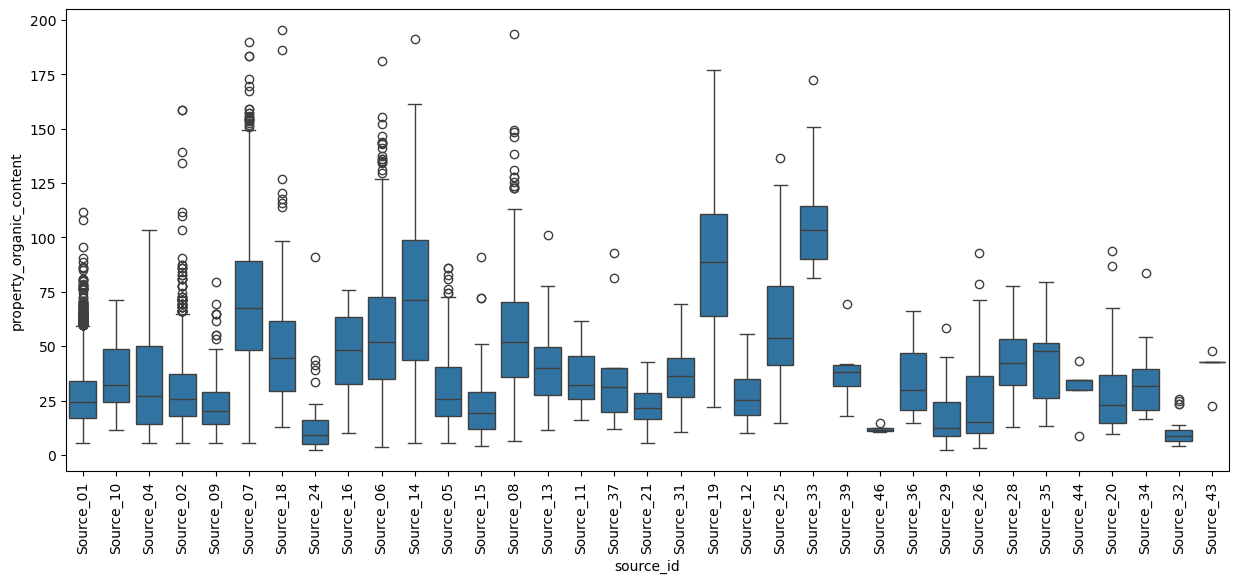

In [18]:
plt.figure(figsize=(15,6))
sns.boxplot(
    data=df,
    x="source_id",
    y="property_organic_content"
)
plt.xticks(rotation=90)
plt.show()

## GroupKFold vs. KFold

In [19]:
mean_rmse_GroupKFold, std_rmse_GroupKFold, _ = evaluate_feature_set(X, y, cat_feats, GroupKFold(n_splits=5))
mean_rmse_KFold, std_rmse_KFold, _ = evaluate_feature_set(X, y, cat_feats, KFold(n_splits=5, shuffle=True, random_state=42))

pd.DataFrame({
    "splitter": ["GroupKFold", "KFold"],
    "mean_RMSE": [mean_rmse_GroupKFold, mean_rmse_KFold],
    "std_RMSE": [std_rmse_GroupKFold, std_rmse_KFold]
})

,splitter,mean_RMSE,std_RMSE
0,GroupKFold,20.451248,8.988818
1,KFold,11.720418,0.614507


## Evaluasi Drop Kolom (Cross-Validation)

In [20]:
def results_to_df(results):
    return pd.DataFrame(
        {
            "experiment": list(results.keys()),
            "mean_RMSE": [v[0] for v in results.values()],
            "std_RMSE": [v[1] for v in results.values()],
        }
    )

In [21]:
band_b_cols = [col for col in X_train.columns if col.startswith("spectral_band_B_PC_")]
missing_indicator_cols = [col for col in X.columns if col.endswith("_is_missing")]

experiments = {
    "full": [],
    "no_cation_na": ["cation_Na", "cation_Na_is_missing"],
    "no_band_b": band_b_cols + ["has_band_B_spectrum"],
    "no_cation_na_band_b": ["cation_Na", "cation_Na_is_missing"]
    + band_b_cols
    + ["has_band_B_spectrum"],
}

In [ ]:
groupkfold_results = run_experiments(X, y, cat_feats, GroupKFold(n_splits=5), experiments)
results_to_df(groupkfold_results)

In [ ]:
kfold_results = run_experiments(X, y, cat_feats, KFold(n_splits=5, shuffle=True, random_state=42), experiments)

# Eksperimen tambahan khusus KFold, "full" tidak dihitung ulang karena sudah ada di kfold_results
extra = run_experiments(
    X, y, cat_feats,
    KFold(n_splits=5, shuffle=True, random_state=42),
    {"no_missing_indicator": missing_indicator_cols},
)
kfold_results.update(extra)

results_to_df(kfold_results)